# Pipeline: `generate_lagged_warping_mts`

Visual decomposition of the lagged-warping generator and the temporal-alignment case study.

Each channel is
$$
X^{(i)}_t \;=\; z\!\bigl(\tau_i + \phi_i(t)\bigr) + \eta^{(i)}_t,
$$
with an AR(1) mother $z$, an integer per-channel lag $\tau_i$, and a monotone warping schedule $\phi_i$ produced by a *rebound* random walk in the $(t_{\rm orig}, t_{\rm warp})$ plane.  Two independent knobs:

- `max_lag` controls the spread of constant lags $\tau_i \in \{0,\dots,\texttt{max\_lag}\}$ (linspace).
- `p_step` controls the rebound-excursion probability and so the non-affine warping content.

Parameters mirror `data/dtw_euclidean/260413_2_lagged-warping_rmse_T1000` (`max_lag=5`, `warp_step_max=3`, $a_{\rm AR}=0.5$, $M=20$, $T=1000$).  Sec. 6 loads the precomputed SPI archives for `pstep ∈ {0.0, 0.3, 0.9}` (all at `max_lag=5`).

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import pearsonr

def _find_project_root() -> Path:
    p = Path.cwd().resolve()
    for parent in [p, *p.parents]:
        if (parent / "data").is_dir() and (parent / "src").is_dir():
            return parent
    raise FileNotFoundError("project root not found")

ROOT = _find_project_root()
sys.path.insert(0, str(ROOT))
from src.generators.linear import generate_lagged_warping_mts

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

In [2]:
# --- Parameters (from saved run meta.json) ---
M = 20
T = 1000
max_lag = 5
warp_step_max = 3
ar1_a = 0.5
ar1_noise_std = 1.0
noise_std = 0.1            # fixed across channels for pedagogical clarity
seed = 0

lags = np.round(np.linspace(0, max_lag, M)).astype(int)
colors = cm.viridis(np.linspace(0, 1, M))

# RUN_DIR used in Sec. 6
RUN_DIR = ROOT / "data" / "dtw_euclidean" / "260413_2_lagged-warping_rmse_T1000"

### 1. AR(1) mother signal $z_t$ (extended to length $T + \texttt{max\_lag}$)

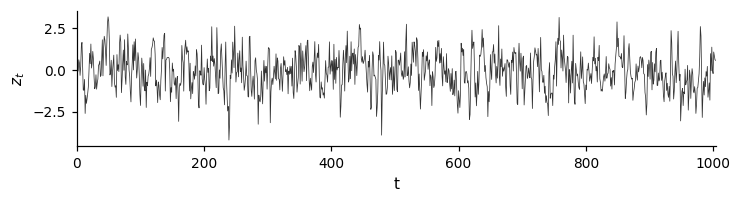

In [3]:
extended_T = T + max_lag
rng_mother = np.random.default_rng(seed)
mother = np.zeros(extended_T)
for t in range(1, extended_T):
    mother[t] = ar1_a * mother[t - 1] + rng_mother.normal(0, ar1_noise_std)

fig, ax = plt.subplots(figsize=(7.5, 1.6))
ax.plot(mother, color="0.2", lw=0.5)
ax.set_xlim(0, extended_T)
ax.set_xlabel("t"); ax.set_ylabel(r"$z_t$")
plt.show()

### 2. Per-channel lags $\tau_i$ (`lag_dist='linspace'`)

Twenty channels, lags evenly spaced and rounded across $\{0,\dots,5\}$ — channel $i$ reads the mother from $\tau_i$ samples in the past.

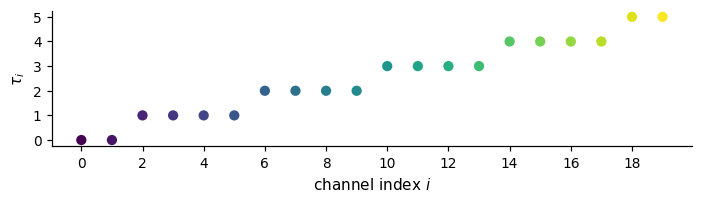

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 1.6))
ax.scatter(np.arange(M), lags, c=colors, s=45, edgecolor="none")
ax.set_xlabel(r"channel index $i$")
ax.set_ylabel(r"$\tau_i$")
ax.set_yticks(range(max_lag + 1))
ax.set_xticks(range(0, M, 2))
plt.show()

### 3. Rebound warping walk → collapsed mapping $\phi(t)$

Left: a random walk in the $(t_{\rm warp}, t_{\rm orig})$ plane.  With probability $p_{\rm step}$ the walk takes an $L$-shaped excursion of size $\texttt{warp\_step\_max}=3$, otherwise it advances diagonally by one step.  The walk always rebounds to the identity diagonal.

Right: each path is collapsed (`_path_to_mapping`) into a monotone non-decreasing integer mapping $\phi:\{1,\dots,T\}\to\{1,\dots,T\}$.  $L$-excursions become *stutters* (horizontal plateaus) — the channel reads the same mother sample for several consecutive output steps.

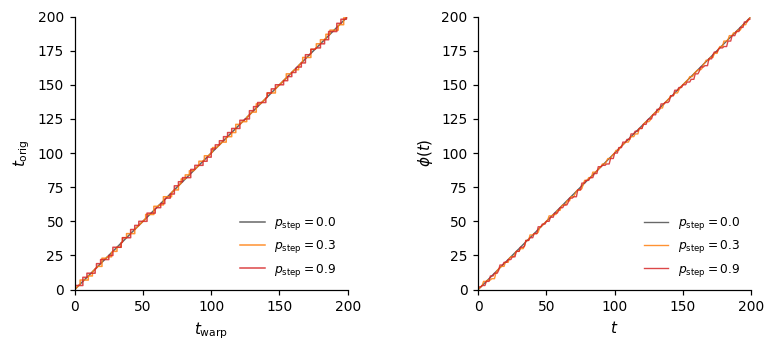

In [5]:
T_viz = 200
p_step_demo = [0.0, 0.3, 0.9]
demo_colors = ["0.3", "tab:orange", "tab:red"]
viz_paths, viz_maps = [], []
for p in p_step_demo:
    _, internals = generate_lagged_warping_mts(
        M=1, T=T_viz, max_lag=0, lag_dist="fixed",
        p_step=p, warp_step_dist="fixed", warp_step_max=warp_step_max,
        noise_std=0.0, noise_std_variable=False,
        ar1_a=ar1_a, ar1_noise_std=ar1_noise_std,
        rng=np.random.default_rng(seed + 1), return_internals=True,
    )
    viz_paths.append(internals.paths[0])
    viz_maps.append(internals.mappings[0])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7.5, 3.3))
ax1.plot([0, T_viz - 1], [0, T_viz - 1], color="0.8", lw=0.6, ls="--", zorder=0)
for path, p, c in zip(viz_paths, p_step_demo, demo_colors):
    ax1.plot(path[:, 1], path[:, 0], color=c, lw=1.0, alpha=0.85,
             label=fr"$p_{{\rm step}}={p}$")
ax1.set_xlim(0, T_viz); ax1.set_ylim(0, T_viz)
ax1.set_aspect("equal")
ax1.set_xlabel(r"$t_{\rm warp}$"); ax1.set_ylabel(r"$t_{\rm orig}$")
ax1.legend(loc="lower right", fontsize=8, frameon=False)

ax2.plot([0, T_viz - 1], [0, T_viz - 1], color="0.8", lw=0.6, ls="--", zorder=0)
for mp, p, c in zip(viz_maps, p_step_demo, demo_colors):
    ax2.plot(np.arange(T_viz), mp, color=c, lw=0.9, alpha=0.85,
             label=fr"$p_{{\rm step}}={p}$")
ax2.set_xlim(0, T_viz); ax2.set_ylim(0, T_viz)
ax2.set_aspect("equal")
ax2.set_xlabel(r"$t$"); ax2.set_ylabel(r"$\phi(t)$")
ax2.legend(loc="lower right", fontsize=8, frameon=False)
plt.tight_layout()
plt.show()

### 4. Channels $X^{(i)}_t = z(\tau_i + \phi_i(t)) + \eta^{(i)}_t$

Stacked MTS at `p_step=0.3` (mild warp on top of linspace lags).  Colour encodes $\tau_i$; channels at the same lag share warp magnitude scale but have independent warping schedules.

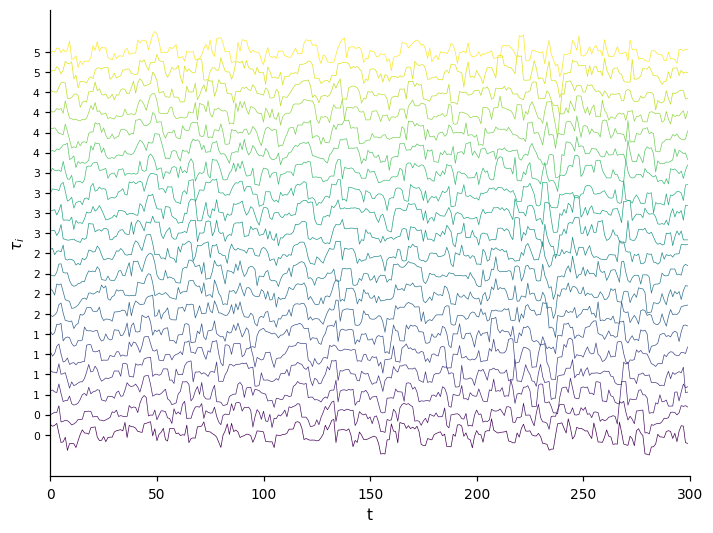

In [6]:
p_step_show = 0.3
data, internals = generate_lagged_warping_mts(
    M=M, T=T, max_lag=max_lag, lag_dist="linspace",
    p_step=p_step_show, warp_step_dist="fixed", warp_step_max=warp_step_max,
    noise_std=noise_std, noise_std_variable=False,
    ar1_a=ar1_a, ar1_noise_std=ar1_noise_std,
    zscore=True, rng=np.random.default_rng(seed), return_internals=True,
)

T_show = 300
offset = 3.0
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for i in range(M):
    ax.plot(data[:T_show, i] + i * offset, color=colors[i], lw=0.45)
ax.set_xlim(0, T_show)
ax.set_xlabel("t")
ax.set_yticks([i * offset for i in range(M)])
ax.set_yticklabels([str(t) for t in internals.lags], fontsize=7)
ax.set_ylabel(r"$\tau_i$")
plt.show()

### 5. What $\mathrm{xpdist}_\tau$ absorbs (lag) vs what it cannot (warp)

Pick the maximally-lagged pair: channel 0 ($\tau{=}0$) and channel 19 ($\tau{=}5$).  Top row: raw overlay $X^{(0)}_t$ vs $X^{(19)}_t$.  Bottom row: shifted overlay $X^{(0)}_t$ vs $X^{(19)}_{t+5}$ — the global shift xpdist would find.

Left column (no warp): the shift recovers near-perfect alignment, so $\mathrm{xpdist}_{\tau\ge 5}\approx 0$, while $\mathrm{pdist}$ remains large.
Right column (heavy warp): residual non-affine misalignment persists after the best rigid shift, so $\mathrm{xpdist} > 0$ even though $\mathrm{DTW}$ would still align them.

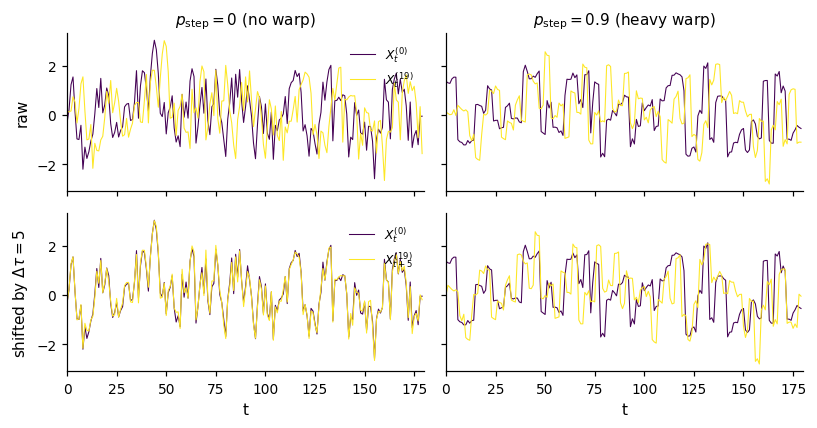

In [7]:
def _generate(p_step_):
    return generate_lagged_warping_mts(
        M=M, T=T, max_lag=max_lag, lag_dist="linspace",
        p_step=p_step_, warp_step_dist="fixed", warp_step_max=warp_step_max,
        noise_std=noise_std, noise_std_variable=False,
        ar1_a=ar1_a, ar1_noise_std=ar1_noise_std,
        zscore=True, rng=np.random.default_rng(seed),
    )

X_nowarp = _generate(0.0)
X_heavy  = _generate(0.9)

i, j, dtau = 0, 19, max_lag
t_view = 180
t = np.arange(t_view)

fig, axes = plt.subplots(2, 2, figsize=(7.5, 4.0), sharex=True, sharey=True)
for col, (X, label) in enumerate([(X_nowarp, r"$p_{\rm step}=0$ (no warp)"),
                                   (X_heavy,  r"$p_{\rm step}=0.9$ (heavy warp)")]):
    axes[0, col].plot(t, X[t, i], color=colors[i], lw=0.7, label=fr"$X^{{({i})}}_t$")
    axes[0, col].plot(t, X[t, j], color=colors[j], lw=0.7, label=fr"$X^{{({j})}}_t$")
    axes[0, col].set_title(label, fontsize=10)

    axes[1, col].plot(t, X[t, i],         color=colors[i], lw=0.7,
                      label=fr"$X^{{({i})}}_t$")
    axes[1, col].plot(t, X[t + dtau, j],  color=colors[j], lw=0.7,
                      label=fr"$X^{{({j})}}_{{t+{dtau}}}$")
    axes[1, col].set_xlabel("t")

axes[0, 0].legend(fontsize=8, frameon=False, loc="upper right")
axes[1, 0].legend(fontsize=8, frameon=False, loc="upper right")
axes[0, 0].set_ylabel("raw")
axes[1, 0].set_ylabel(fr"shifted by $\Delta\tau{{=}}{dtau}$")
for ax in axes.flat:
    ax.set_xlim(0, t_view)
plt.tight_layout()
plt.show()

### 6. SPI–SPI triplet across the $p_{\rm step}$ sweep (`max_lag=5` fixed)

Off-diagonal entries of $\mathrm{MPI}_{\rm pdist}$, $\mathrm{MPI}_{\mathrm{xpdist}_{\tau=10}}$, and $\mathrm{MPI}_{\rm DTW}$ plotted pair-against-pair, one row per regime, from the saved `spi_mpis.npz` archives.  Pearson $f_{kl}$ annotated.

**Reading the panel.**  None of the three SPIs alone discriminates lag from warp: each is a scalar distance.  The discriminating signal is *emergent at the pair level*.

- **Row 1** (`p_step=0`, lag only): xpdist absorbs the constant shift; DTW also absorbs it; pdist does not.  So $f(\mathrm{xpdist},\mathrm{DTW})\approx 1$ (left of the row), while $f(\mathrm{pdist},\cdot)$ are depressed.  The triplet diagnoses *lag-only*.
- **Row 3** (`p_step=0.9`, lag + heavy warp): DTW follows the warp, xpdist cannot.  $f(\mathrm{xpdist},\mathrm{DTW})$ now drops, joining the other two coordinates.  The triplet diagnoses *lag + warp*.
- **Row 2** (`p_step=0.3`): intermediate.

Pairing with Case 1's $\{r,\rho,\mathrm{MI}\}$ triplet, the union covers pointwise dependency character (linear / monotone-nonlinear / non-monotone) and temporal alignment character (identity / constant shift / non-affine warp).

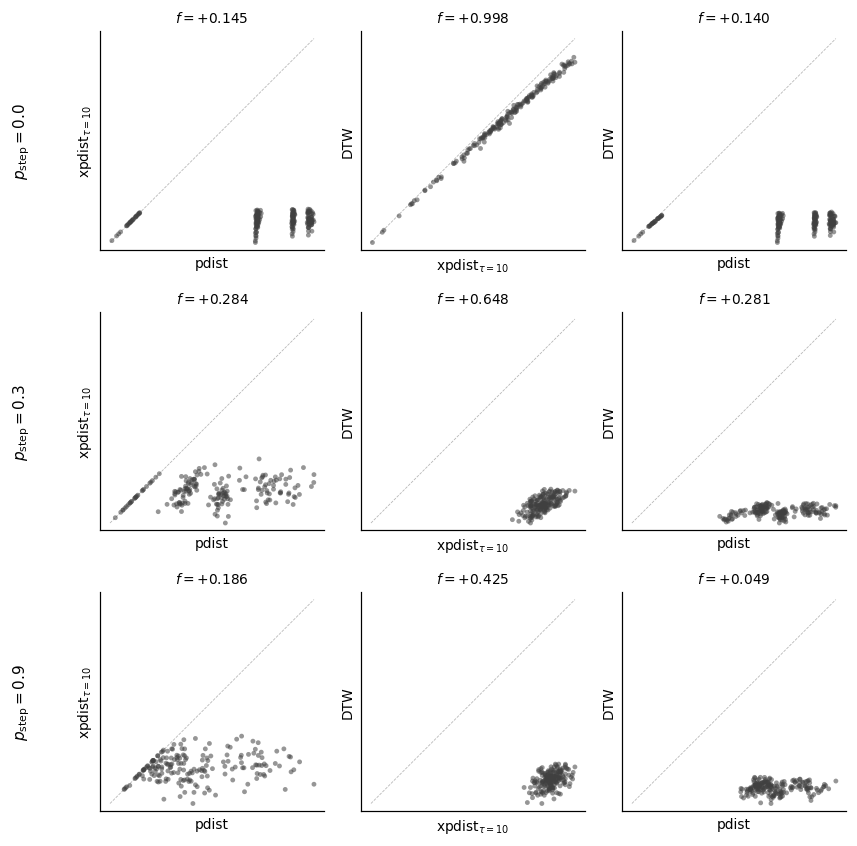

In [8]:
spi_names = ["pdist_euclidean_rmse",
             "xpdist_euclidean_tau-10_min_rmse",
             "dtw_rmse"]
spi_labels = [r"pdist", r"xpdist$_{\tau=10}$", r"DTW"]
spi_pairs = [(0, 1), (1, 2), (0, 2)]
regimes = [("0.0", r"$p_{\rm step}=0.0$"),
           ("0.3", r"$p_{\rm step}=0.3$"),
           ("0.9", r"$p_{\rm step}=0.9$")]
iu = np.triu_indices(M, k=1)

fig, axes = plt.subplots(3, 3, figsize=(7.8, 7.8))
for r, (p_str, regime_label) in enumerate(regimes):
    ds = RUN_DIR / f"pstep-{p_str}_maxlag-5" / "M20_T1000_I0" / "spi_mpis.npz"
    mpis = np.load(ds)
    for c, (a, b) in enumerate(spi_pairs):
        ax = axes[r, c]
        x = mpis[spi_names[a]][iu]
        y = mpis[spi_names[b]][iu]
        ax.scatter(x, y, s=10, alpha=0.55, color="0.25", edgecolor="none")
        r_val = pearsonr(x, y)[0]
        lo = min(x.min(), y.min()); hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], color="0.7", lw=0.5, ls="--", zorder=0)
        ax.set_aspect("equal", adjustable="datalim")
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_xlabel(spi_labels[a], fontsize=9)
        ax.set_ylabel(spi_labels[b], fontsize=9)
        ax.set_title(fr"$f={r_val:+.3f}$", fontsize=9)
    axes[r, 0].annotate(regime_label, xy=(-0.35, 0.5),
                        xycoords="axes fraction", rotation=90,
                        ha="center", va="center", fontsize=10)
plt.tight_layout()
plt.show()